## Model-Free Analysis Loss Search

It is interesting that doing a grid search with uniform MFA loss weights can help us converge to empirical MFA characteristics. We will perform iterative searches to define a closer scope. There may still likely be a shift of sorts in the MFA graphs, but this search will get us to the closest simulation given parameters. 

In [4]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))

In [6]:
from ast import literal_eval
from simulation import get_corrected_empirical_distributions
import pandas as pd
import numpy as np

df_raw = pd.read_csv('../1ms_trial_data.csv')
df_raw['RT'] = df_raw['RT']*1000 # adjustment for RT
df_raw['fixation'] = df_raw['fixation'].apply(literal_eval)

to_drop = pd.read_csv("../dropped_trials.csv").rename(columns={"parcode": "sub_id"})

df = df_raw[
    ~df_raw.set_index(["sub_id", "trial"]).index.isin(
        to_drop.set_index(["sub_id", "trial"]).index
    )
]

sub_ids = np.unique(df['sub_id'])

size = 30
sample_sub_ids = np.random.choice(sub_ids, size=size, replace=False)

sample_df = df[df["sub_id"].isin(sample_sub_ids)]
sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})

value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'
cutoff = 0.95

empirical_distributions = get_corrected_empirical_distributions(
    sample_df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=cutoff
)

/var/folders/8r/t10vclyx7wb951lg8h5g2jrd33843d/T/ipykernel_42841/1526266820.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})


In [7]:
from pyddm.preprocessing.dataset import rasterize_data
from mfa import compute_mfa

samples_rasterized = rasterize_data(sample_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
samples_rasterized['fix_dur'] = samples_rasterized.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

samples_rasterized['fix_num'] = (
    samples_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

samples_rasterized['fix_num_rev'] = (
    samples_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)

samp_mfa = compute_mfa(samples_rasterized)

ModuleNotFoundError: No module named 'pyddm.preprocessing'

In [5]:
from simulation import get_corrected_empirical_distributions, generate_fixations

value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'
cutoff = 0.95

empirical_distributions = get_corrected_empirical_distributions(
    sample_df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=cutoff
)

trials = sample_df.loc[:, ['avgWTP_left', 'avgWTP_right']]
trials['fixation'] = None

dt = 0.01

rows = []
for idx, r in trials.iterrows():
    fx = generate_fixations(dt, r.avgWTP_left - r.avgWTP_right, empirical_distributions)
    if fx is not None:
        rows.append((idx, fx))

trials_clean = trials.loc[[i for i, _ in rows]].copy()
trials_clean['fixation'] = [fx for _, fx in rows]
my_trials = trials_clean.to_dict(orient="records")

In [6]:
from mfa import model_free_loss
from simulation import simulate
import itertools

dt = 0.01
seed = 42

d_vals = np.linspace(0.35, 0.65, 5)
noise_vals = np.linspace(0.4, 0.8, 5)

grid = list(itertools.product(d_vals, noise_vals))

results = []

for d_val, noise_val in grid:
    model_conditions = {'drift_rate': d_val, 'theta': 0.5, 'noise': noise_val}

    temp_trials = trials.copy()

    print(f"Simulating with params [{d_val}, {noise_val}]...")

    results_df = simulate(dt, model_conditions, my_trials, seed=seed, save_results=False)
    results_df['sub_id'] = f'seed{seed}_subjects{size}_sim'
    results_df['trial'] = range(1, len(trials_clean) + 1)
    # results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
    results_df = results_df.drop(columns = ['trajectory'])

    results_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
    results_rasterized['fix_dur'] = results_rasterized.apply(
        lambda r: r['fix_end'] - r['fix_start'],
        axis=1
    )

    results_rasterized['fix_num'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount() + 1
    )

    results_rasterized['fix_num_rev'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount(ascending=False) + 1
    )

    sim_mfa = compute_mfa(results_rasterized)
    loss = model_free_loss(samp_mfa, sim_mfa)

    print(f"MFA loss = {loss}")
    
    results.append({"drift": d_val, "noise": noise_val, "mfa_loss": loss})

Simulating with params [0.35, 0.4]...
MFA loss = 66482.11917474787
Simulating with params [0.35, 0.5]...
MFA loss = 52965.4565414738
Simulating with params [0.35, 0.6000000000000001]...
MFA loss = 49665.11472029279
Simulating with params [0.35, 0.7000000000000001]...
MFA loss = 49113.15026579592
Simulating with params [0.35, 0.8]...
MFA loss = 54382.08978426524
Simulating with params [0.425, 0.4]...
MFA loss = 59036.08686660002
Simulating with params [0.425, 0.5]...
MFA loss = 51883.55340718037
Simulating with params [0.425, 0.6000000000000001]...
MFA loss = 49095.83480777953
Simulating with params [0.425, 0.7000000000000001]...
MFA loss = 48840.585746435725
Simulating with params [0.425, 0.8]...
MFA loss = 52687.27130784683
Simulating with params [0.5, 0.4]...
MFA loss = 57614.26698883994
Simulating with params [0.5, 0.5]...
MFA loss = 51919.48866857243
Simulating with params [0.5, 0.6000000000000001]...
MFA loss = 49093.3348677284
Simulating with params [0.5, 0.7000000000000001]...
M

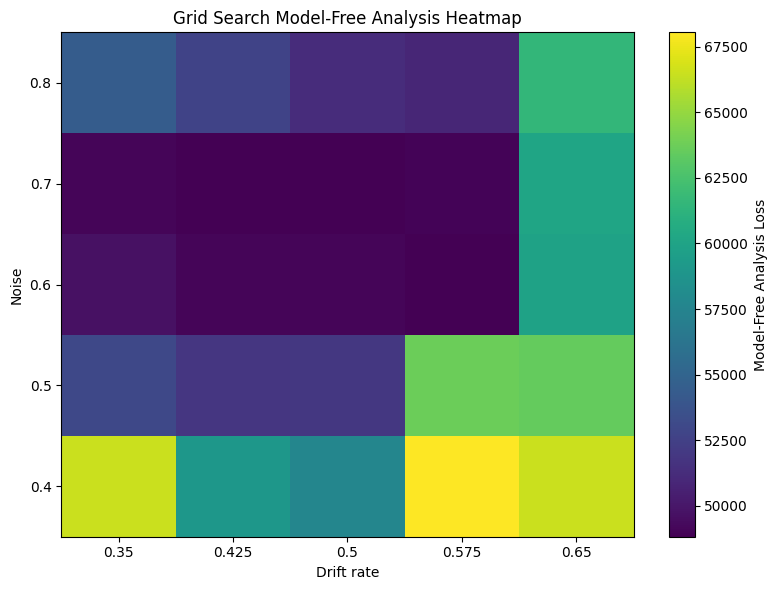

In [8]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)

heatmap_data = results_df.pivot(
    index="noise",
    columns="drift",
    values="mfa_loss"
)

plt.figure(figsize=(8,6))
im = plt.imshow(
    heatmap_data.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Model-Free Analysis Loss")

plt.xticks(
    range(len(heatmap_data.columns)),
    labels=np.round(heatmap_data.columns, 3)
)
plt.yticks(
    range(len(heatmap_data.index)),
    labels=np.round(heatmap_data.index, 3)
)

plt.xlabel("Drift rate")
plt.ylabel("Noise")
plt.title("Grid Search Model-Free Analysis Heatmap")
plt.tight_layout()
plt.show()

In [11]:
results_df.loc[results_df['mfa_loss'] == min(results_df["mfa_loss"])]

,drift,noise,mfa_loss
13,0.5,0.7,48824.312893


In [12]:
d_vals = np.linspace(0.5, 2.0, 4)
noise_vals = np.linspace(0.2, 1.0, 5)

large_grid = list(itertools.product(d_vals, noise_vals))

small_theta_results = []

for d_val, noise_val in large_grid:
    model_conditions = {'drift_rate': d_val, 'theta': 0.3, 'noise': noise_val}

    temp_trials = trials.copy()

    print(f"Simulating with params [{d_val}, {noise_val}]...")

    results_df = simulate(dt, model_conditions, my_trials, seed=seed, save_results=False)
    results_df['sub_id'] = f'seed{seed}_subjects{size}_sim'
    results_df['trial'] = range(1, len(trials_clean) + 1)
    # results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
    results_df = results_df.drop(columns = ['trajectory'])

    results_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
    results_rasterized['fix_dur'] = results_rasterized.apply(
        lambda r: r['fix_end'] - r['fix_start'],
        axis=1
    )

    results_rasterized['fix_num'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount() + 1
    )

    results_rasterized['fix_num_rev'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount(ascending=False) + 1
    )

    sim_mfa = compute_mfa(results_rasterized)
    loss = model_free_loss(samp_mfa, sim_mfa)

    print(f"MFA loss = {loss}")
    
    small_theta_results.append({"drift": d_val, "noise": noise_val, "mfa_loss": loss})

Simulating with params [0.5, 0.2]...
MFA loss = 65869.0468665854
Simulating with params [0.5, 0.4]...
MFA loss = 57310.80122375037
Simulating with params [0.5, 0.6000000000000001]...
MFA loss = 49841.80223673773
Simulating with params [0.5, 0.8]...
MFA loss = 50360.264664817645
Simulating with params [0.5, 1.0]...


/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:188: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  errors = np.array([sem(first), sem(middle), sem(last)])


MFA loss = nan
Simulating with params [1.0, 0.2]...
MFA loss = 72383.82835032154
Simulating with params [1.0, 0.4]...
MFA loss = 84486.20424311563
Simulating with params [1.0, 0.6000000000000001]...
MFA loss = 83752.5017942349
Simulating with params [1.0, 0.8]...
MFA loss = 75064.67802018316
Simulating with params [1.0, 1.0]...
MFA loss = 80993.37165113629
Simulating with params [1.5, 0.2]...
MFA loss = 86177.11511364667
Simulating with params [1.5, 0.4]...
MFA loss = 85953.29712292778
Simulating with params [1.5, 0.6000000000000001]...
MFA loss = 85676.62619955027
Simulating with params [1.5, 0.8]...
MFA loss = 88720.06303525293
Simulating with params [1.5, 1.0]...
MFA loss = 92689.67633286696
Simulating with params [2.0, 0.2]...
MFA loss = 87946.15121486854
Simulating with params [2.0, 0.4]...
MFA loss = 87359.85948038392
Simulating with params [2.0, 0.6000000000000001]...
MFA loss = 87381.4204384361
Simulating with params [2.0, 0.8]...
MFA loss = 90176.57946832123
Simulating with pa

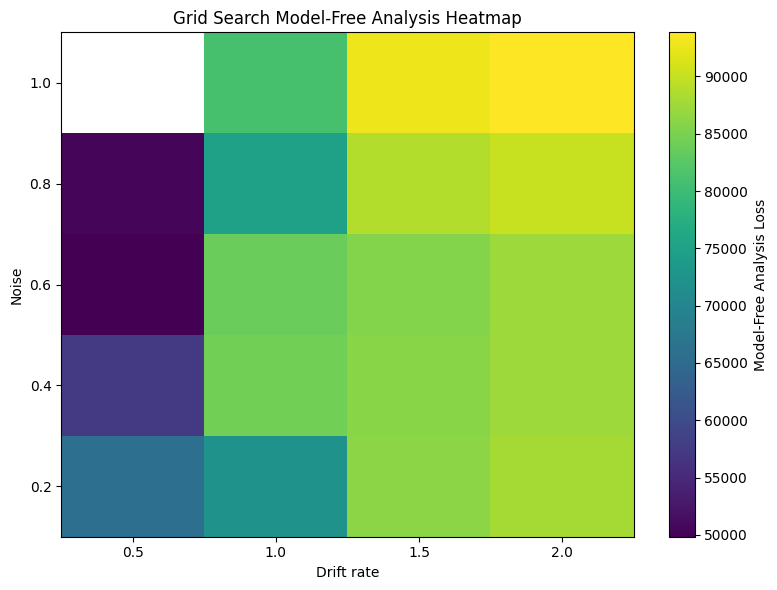

In [ ]:
small_theta_results_df = pd.DataFrame(small_theta_results)

small_theta_heatmap_data = small_theta_results_df.pivot(
    index="noise",
    columns="drift",
    values="mfa_loss"
)

plt.figure(figsize=(8,6))
im = plt.imshow(
    small_theta_heatmap_data.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Model-Free Analysis Loss")

plt.xticks(
    range(len(small_theta_heatmap_data.columns)),
    labels=np.round(small_theta_heatmap_data.columns, 3)
)
plt.yticks(
    range(len(small_theta_heatmap_data.index)),
    labels=np.round(small_theta_heatmap_data.index, 3)
)

plt.xlabel("Drift rate")
plt.ylabel("Noise")
plt.title("Grid Search Model-Free Analysis Heatmap")
plt.tight_layout()
plt.show()

In [14]:
d_vals = np.linspace(0.3, 0.6, 5)
noise_vals = np.linspace(0.5, 0.9, 5)

small_theta_grid = list(itertools.product(d_vals, noise_vals))

small_theta_precise_results = []

for d_val, noise_val in small_theta_grid:
    model_conditions = {'drift_rate': d_val, 'theta': 0.3, 'noise': noise_val}

    temp_trials = trials.copy()

    print(f"Simulating with params [{d_val}, {noise_val}]...")

    results_df = simulate(dt, model_conditions, my_trials, seed=seed, save_results=False)
    results_df['sub_id'] = f'seed{seed}_subjects{size}_sim'
    results_df['trial'] = range(1, len(trials_clean) + 1)
    # results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
    results_df = results_df.drop(columns = ['trajectory'])

    results_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
    results_rasterized['fix_dur'] = results_rasterized.apply(
        lambda r: r['fix_end'] - r['fix_start'],
        axis=1
    )

    results_rasterized['fix_num'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount() + 1
    )

    results_rasterized['fix_num_rev'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount(ascending=False) + 1
    )

    sim_mfa = compute_mfa(results_rasterized)
    loss = model_free_loss(samp_mfa, sim_mfa)

    print(f"MFA loss = {loss}")
    
    small_theta_precise_results.append({"drift": d_val, "noise": noise_val, "mfa_loss": loss})

Simulating with params [0.3, 0.5]...
MFA loss = 58324.36266724786
Simulating with params [0.3, 0.6]...
MFA loss = 51099.11346980844
Simulating with params [0.3, 0.7]...
MFA loss = 49820.33484741934
Simulating with params [0.3, 0.8]...
MFA loss = 55153.82575110347
Simulating with params [0.3, 0.9]...


/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:188: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  errors = np.array([sem(first), sem(middle), sem(last)])


MFA loss = nan
Simulating with params [0.375, 0.5]...
MFA loss = 55518.88606432358
Simulating with params [0.375, 0.6]...
MFA loss = 50324.67925493112
Simulating with params [0.375, 0.7]...
MFA loss = 49094.80042679205
Simulating with params [0.375, 0.8]...
MFA loss = 52655.66585005632
Simulating with params [0.375, 0.9]...
MFA loss = 107217.36609298606
Simulating with params [0.44999999999999996, 0.5]...
MFA loss = 54633.447541513626
Simulating with params [0.44999999999999996, 0.6]...
MFA loss = 50000.10808538074
Simulating with params [0.44999999999999996, 0.7]...
MFA loss = 48823.76201145335
Simulating with params [0.44999999999999996, 0.8]...
MFA loss = 50897.73978997459
Simulating with params [0.44999999999999996, 0.9]...
MFA loss = 59412.15757932673
Simulating with params [0.5249999999999999, 0.5]...
MFA loss = 54204.7265957018
Simulating with params [0.5249999999999999, 0.6]...
MFA loss = 49721.06176777844
Simulating with params [0.5249999999999999, 0.7]...
MFA loss = 48589.881

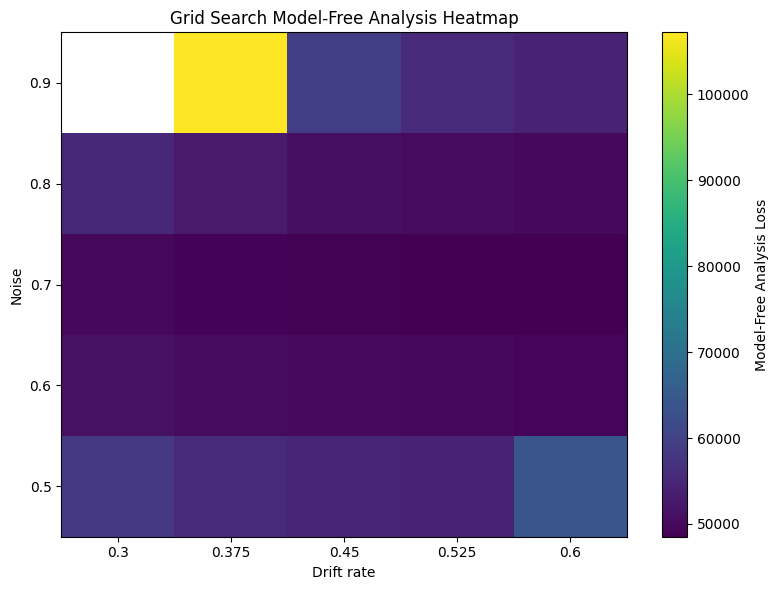

In [15]:
small_theta_precise_results_df = pd.DataFrame(small_theta_precise_results)

small_theta_precise_heatmap_data = small_theta_precise_results_df.pivot(
    index="noise",
    columns="drift",
    values="mfa_loss"
)

plt.figure(figsize=(8,6))
im = plt.imshow(
    small_theta_precise_heatmap_data.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Model-Free Analysis Loss")

plt.xticks(
    range(len(small_theta_precise_heatmap_data.columns)),
    labels=np.round(small_theta_precise_heatmap_data.columns, 3)
)
plt.yticks(
    range(len(small_theta_precise_heatmap_data.index)),
    labels=np.round(small_theta_precise_heatmap_data.index, 3)
)

plt.xlabel("Drift rate")
plt.ylabel("Noise")
plt.title("Grid Search Model-Free Analysis Heatmap")
plt.tight_layout()
plt.show()

In [17]:
small_theta_precise_results_df.loc[small_theta_precise_results_df['mfa_loss'] == min(small_theta_precise_results_df["mfa_loss"])]

,drift,noise,mfa_loss
22,0.6,0.7,48513.528446


In [18]:
large_theta_results = []

for d_val, noise_val in large_grid:
    model_conditions = {'drift_rate': d_val, 'theta': 0.7, 'noise': noise_val}

    temp_trials = trials.copy()

    print(f"Simulating with params [{d_val}, {noise_val}]...")

    results_df = simulate(dt, model_conditions, my_trials, seed=seed, save_results=False)
    results_df['sub_id'] = f'seed{seed}_subjects{size}_sim'
    results_df['trial'] = range(1, len(trials_clean) + 1)
    results_df = results_df.drop(columns = ['trajectory'])

    results_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
    results_rasterized['fix_dur'] = results_rasterized.apply(
        lambda r: r['fix_end'] - r['fix_start'],
        axis=1
    )

    results_rasterized['fix_num'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount() + 1
    )

    results_rasterized['fix_num_rev'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount(ascending=False) + 1
    )

    sim_mfa = compute_mfa(results_rasterized)
    loss = model_free_loss(samp_mfa, sim_mfa)

    print(f"MFA loss = {loss}")
    
    large_theta_results.append({"drift": d_val, "noise": noise_val, "mfa_loss": loss})

Simulating with params [0.5, 0.2]...
MFA loss = 110218.77492625426
Simulating with params [0.5, 0.4]...
MFA loss = 56180.993396184225
Simulating with params [0.5, 0.6000000000000001]...
MFA loss = 48677.16639649813
Simulating with params [0.5, 0.8]...
MFA loss = 53313.23339913468
Simulating with params [0.5, 1.0]...


/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:188: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  errors = np.array([sem(first), sem(middle), sem(last)])


MFA loss = nan
Simulating with params [1.0, 0.2]...
MFA loss = 92760.94939586137
Simulating with params [1.0, 0.4]...
MFA loss = 89103.2089045203
Simulating with params [1.0, 0.6000000000000001]...
MFA loss = 73721.70994497623
Simulating with params [1.0, 0.8]...
MFA loss = 75889.4866221191
Simulating with params [1.0, 1.0]...
MFA loss = 99430.05251525722
Simulating with params [1.5, 0.2]...
MFA loss = 88339.72411218043
Simulating with params [1.5, 0.4]...
MFA loss = 89289.66685642503
Simulating with params [1.5, 0.6000000000000001]...
MFA loss = 87424.44482097162
Simulating with params [1.5, 0.8]...
MFA loss = 90066.19407268442
Simulating with params [1.5, 1.0]...
MFA loss = 104743.20327510533
Simulating with params [2.0, 0.2]...
MFA loss = 88077.41214872392
Simulating with params [2.0, 0.4]...
MFA loss = 88345.13835492311
Simulating with params [2.0, 0.6000000000000001]...
MFA loss = 88391.56629823818
Simulating with params [2.0, 0.8]...
MFA loss = 91049.17820638503
Simulating with p

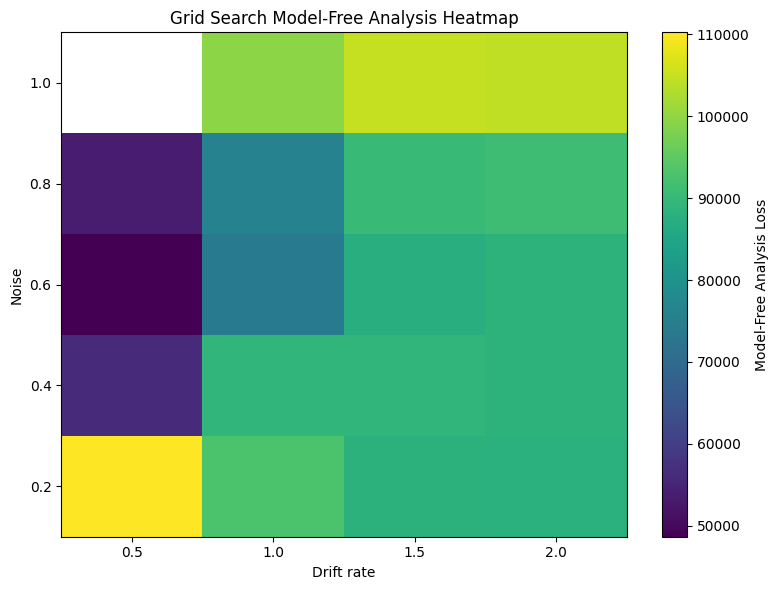

In [19]:
large_theta_results_df = pd.DataFrame(large_theta_results)

large_theta_heatmap_data = large_theta_results_df.pivot(
    index="noise",
    columns="drift",
    values="mfa_loss"
)

plt.figure(figsize=(8,6))
im = plt.imshow(
    large_theta_heatmap_data.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Model-Free Analysis Loss")

plt.xticks(
    range(len(large_theta_heatmap_data.columns)),
    labels=np.round(large_theta_heatmap_data.columns, 3)
)
plt.yticks(
    range(len(large_theta_heatmap_data.index)),
    labels=np.round(large_theta_heatmap_data.index, 3)
)

plt.xlabel("Drift rate")
plt.ylabel("Noise")
plt.title("Grid Search Model-Free Analysis Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
d_vals = np.linspace(0.35, 0.65, 5)
noise_vals = np.linspace(0.4, 0.8, 5)

large_theta_precise_grid = list(itertools.product(d_vals, noise_vals))

large_theta_precise_results = []
for d_val, noise_val in large_theta_precise_grid:
    model_conditions = {'drift_rate': d_val, 'theta': 0.5, 'noise': noise_val}

    temp_trials = trials.copy() # Fix

    print(f"Simulating with params [{d_val}, {noise_val}]...")

    results_df = simulate(dt, model_conditions, my_trials, seed=seed, save_results=False)
    results_df['sub_id'] = f'seed{seed}_subjects{size}_sim'
    results_df['trial'] = range(1, len(trials_clean) + 1)
    # results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
    results_df = results_df.drop(columns = ['trajectory'])

    results_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
    results_rasterized['fix_dur'] = results_rasterized.apply(
        lambda r: r['fix_end'] - r['fix_start'],
        axis=1
    )

    results_rasterized['fix_num'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount() + 1
    )

    results_rasterized['fix_num_rev'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount(ascending=False) + 1
    )

    sim_mfa = compute_mfa(results_rasterized)
    loss = model_free_loss(samp_mfa, sim_mfa)

    print(f"MFA loss = {loss}")
    
    large_theta_precise_results.append({"drift": d_val, "noise": noise_val, "mfa_loss": loss})

Simulating with params [0.35, 0.4]...
MFA loss = 66482.11917474787
Simulating with params [0.35, 0.5]...
MFA loss = 52965.4565414738
Simulating with params [0.35, 0.6000000000000001]...
MFA loss = 49665.11472029279
Simulating with params [0.35, 0.7000000000000001]...
MFA loss = 49113.15026579592
Simulating with params [0.35, 0.8]...
MFA loss = 54382.08978426524
Simulating with params [0.425, 0.4]...
MFA loss = 59036.08686660002
Simulating with params [0.425, 0.5]...
MFA loss = 51883.55340718037
Simulating with params [0.425, 0.6000000000000001]...
MFA loss = 49095.83480777953
Simulating with params [0.425, 0.7000000000000001]...
MFA loss = 48840.585746435725
Simulating with params [0.425, 0.8]...
MFA loss = 52687.27130784683
Simulating with params [0.5, 0.4]...
MFA loss = 57614.26698883994
Simulating with params [0.5, 0.5]...
MFA loss = 51919.48866857243
Simulating with params [0.5, 0.6000000000000001]...
MFA loss = 49093.3348677284
Simulating with params [0.5, 0.7000000000000001]...
M

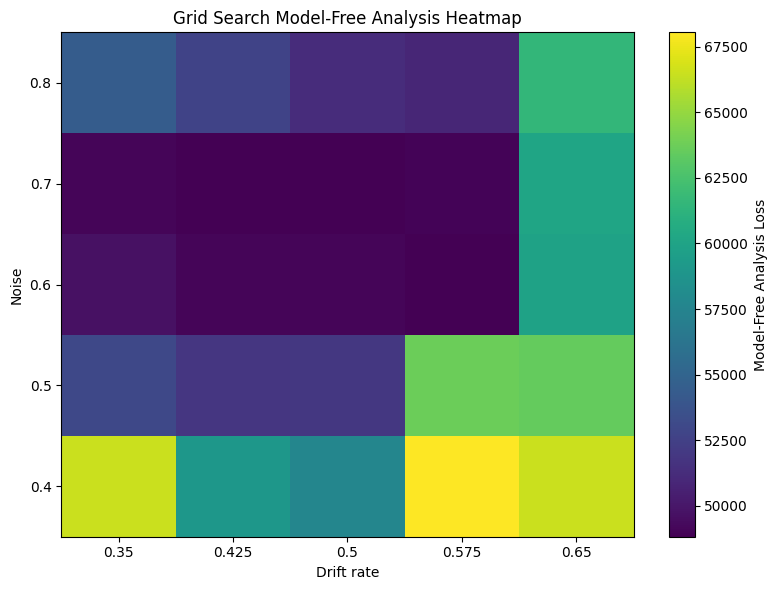

In [21]:
large_theta_precise_results_df = pd.DataFrame(large_theta_precise_results)

large_theta_precise_heatmap_data = large_theta_precise_results_df.pivot(
    index="noise",
    columns="drift",
    values="mfa_loss"
)

plt.figure(figsize=(8,6))
im = plt.imshow(
    large_theta_precise_heatmap_data.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Model-Free Analysis Loss")

plt.xticks(
    range(len(large_theta_precise_heatmap_data.columns)),
    labels=np.round(large_theta_precise_heatmap_data.columns, 3)
)
plt.yticks(
    range(len(large_theta_precise_heatmap_data.index)),
    labels=np.round(large_theta_precise_heatmap_data.index, 3)
)

plt.xlabel("Drift rate")
plt.ylabel("Noise")
plt.title("Grid Search Model-Free Analysis Heatmap")
plt.tight_layout()
plt.show()

In [23]:
large_theta_precise_results_df.loc[large_theta_precise_results_df["mfa_loss"] == min(large_theta_precise_results_df["mfa_loss"])]

,drift,noise,mfa_loss
13,0.5,0.7,48824.312893


Let's inspect this combo of drift = 0.5, theta = 0.5, noise = 0.7.

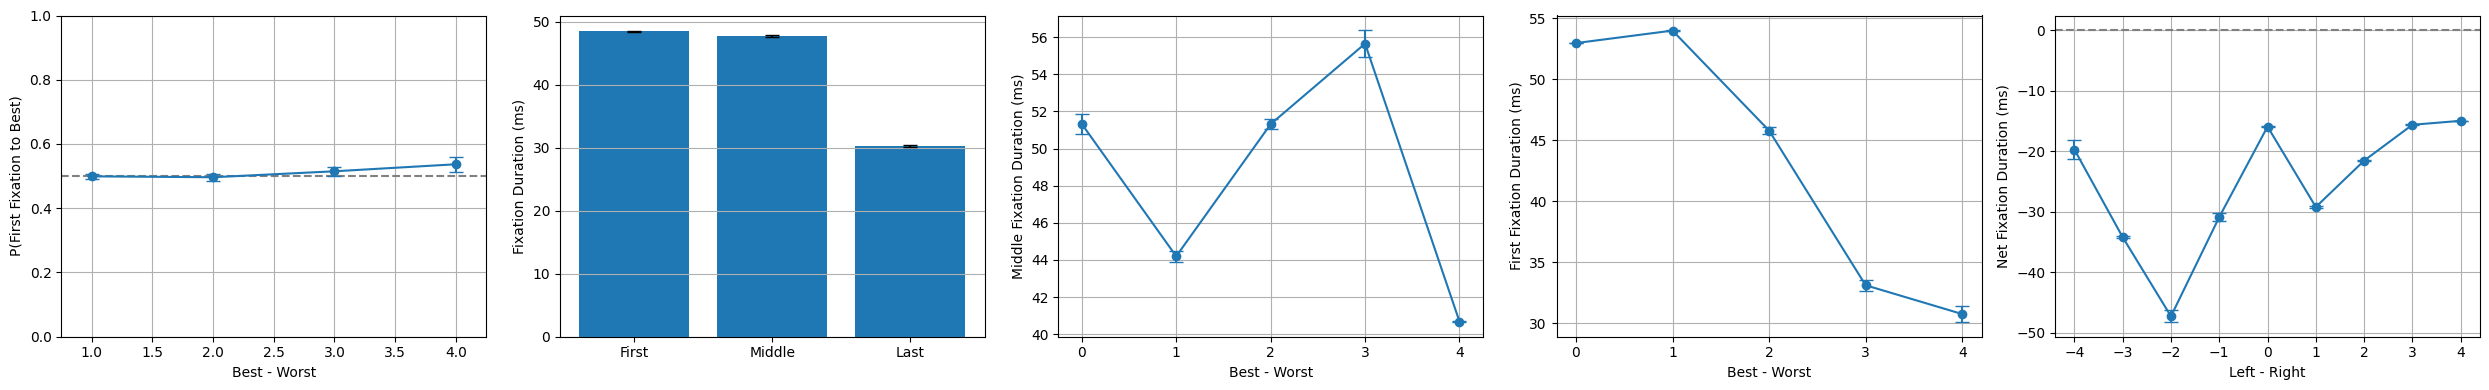

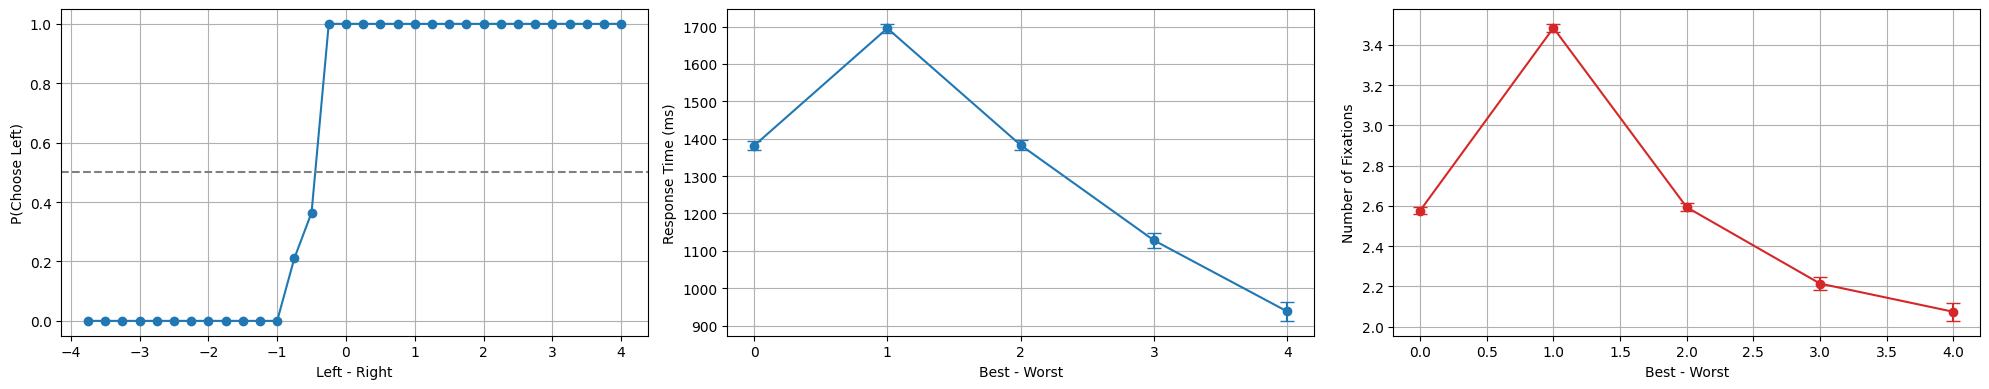

In [25]:
from mfa import plot_basic_psychometrics, plot_fixation_properties

model_conditions = {'drift_rate': 0.5, 'theta': 0.5, 'noise': 0.7}

results_df = simulate(dt, model_conditions, my_trials, seed=seed, save_results=False)
results_df['sub_id'] = f'seed{seed}_subjects{size}_sim'
results_df['trial'] = range(1, len(trials_clean) + 1)
results_df = results_df.drop(columns = ['trajectory'])

results_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
results_rasterized['fix_dur'] = results_rasterized.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

results_rasterized['fix_num'] = (
    results_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

results_rasterized['fix_num_rev'] = (
    results_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)

plot_fixation_properties(results_rasterized)
plot_basic_psychometrics(results_rasterized)

This grid search strategy did not turn out as successful. There's two main reasons for this. First, the weights that I assigned to each plot was arbitrary. If we do not know the true importance of each model-free analysis characteristic, then we cannot judge the quality of data. I also arbitrarily assigned missing bins a constant penalty. This may have contributed to the error. Second, the scale of the RT's were very wrong. We'll move forward with another method.